In [1]:
import netket as nk
import netket.experimental as nkx
import numpy as np
import matplotlib.pyplot as plt
import json
from flax import nnx
import jax.numpy as jnp
import jax 

L = 4  # take a 1x4 lattice
D = 1
t = 1.0  # tunneling/hopping
U = 0.1  # coulomb
# create the graph our fermions can hop on
g = nk.graph.Hypercube(length=L, n_dim=D, pbc=False)
n_sites = g.n_nodes
# create a hilbert space with 2 up and 2 down spins
hilber_space = nk.hilbert.SpinOrbitalFermions(n_sites, s=1 / 2, n_fermions_per_spin=(2, 2))
ham = nkx.operator.FermiHubbardJax(hilber_space, t=t, U=U, graph=g)

sampler = nk.sampler.MetropolisFermionHop(hilber_space, graph=g, n_chains=16, sweep_size=64)
# or let netket copy the graph per spin sector

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


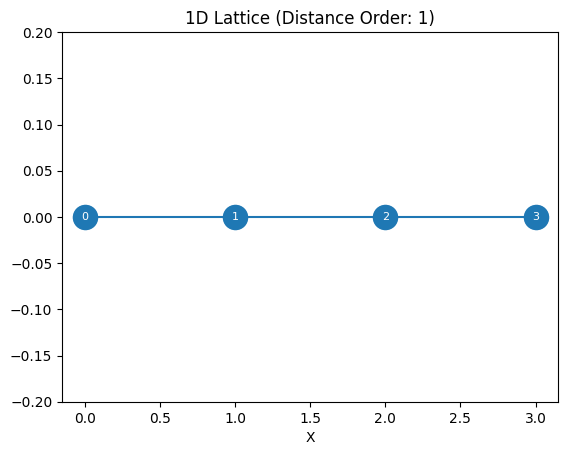

<Axes: title={'center': '1D Lattice (Distance Order: 1)'}, xlabel='X'>

In [12]:
g.draw()

In [49]:
hilber_space.all_states()

Array([[0, 0, 1, 1, 0, 0, 1, 1],
       [0, 0, 1, 1, 0, 1, 0, 1],
       [0, 0, 1, 1, 0, 1, 1, 0],
       [0, 0, 1, 1, 1, 0, 0, 1],
       [0, 0, 1, 1, 1, 0, 1, 0],
       [0, 0, 1, 1, 1, 1, 0, 0],
       [0, 1, 0, 1, 0, 0, 1, 1],
       [0, 1, 0, 1, 0, 1, 0, 1],
       [0, 1, 0, 1, 0, 1, 1, 0],
       [0, 1, 0, 1, 1, 0, 0, 1],
       [0, 1, 0, 1, 1, 0, 1, 0],
       [0, 1, 0, 1, 1, 1, 0, 0],
       [0, 1, 1, 0, 0, 0, 1, 1],
       [0, 1, 1, 0, 0, 1, 0, 1],
       [0, 1, 1, 0, 0, 1, 1, 0],
       [0, 1, 1, 0, 1, 0, 0, 1],
       [0, 1, 1, 0, 1, 0, 1, 0],
       [0, 1, 1, 0, 1, 1, 0, 0],
       [1, 0, 0, 1, 0, 0, 1, 1],
       [1, 0, 0, 1, 0, 1, 0, 1],
       [1, 0, 0, 1, 0, 1, 1, 0],
       [1, 0, 0, 1, 1, 0, 0, 1],
       [1, 0, 0, 1, 1, 0, 1, 0],
       [1, 0, 0, 1, 1, 1, 0, 0],
       [1, 0, 1, 0, 0, 0, 1, 1],
       [1, 0, 1, 0, 0, 1, 0, 1],
       [1, 0, 1, 0, 0, 1, 1, 0],
       [1, 0, 1, 0, 1, 0, 0, 1],
       [1, 0, 1, 0, 1, 0, 1, 0],
       [1, 0, 1, 0, 1, 1, 0, 0],
       [1,

In [ ]:
class FFN(nnx.Module):

    def __init__(self, N: int, alpha: int = 1, *, rngs: nnx.Rngs):
        """
        Construct a Feed-Forward Neural Network with a single hidden layer.

        Args:
            N: The number of input nodes (number of spins in the chain).
            alpha: The density of the hidden layer. The hidden layer will have
                N*alpha nodes.
            rngs: The random number generator seed.
        """
        self.alpha = alpha

        # We define a linear (or dense) layer with `alpha` times the number of input nodes
        # as output nodes.
        # We must pass forward the rngs object to the dense layer.
        self.linear = nnx.Linear(in_features=N, out_features=alpha * N, rngs=rngs)

    def __call__(self, x: jax.Array):
        #print(f"x.shape = {x.shape}|x ={x}")

        # we apply the linear layer to the input
        y = self.linear(x)

        # the non-linearity is a simple ReLu
        y = nnx.relu(y)

        # sum the output
        return jnp.sum(y, axis=-1)
    
model_FNN = FFN(N=L*2, alpha=2, rngs=nnx.Rngs(2))
vstate_FNN = nk.vqs.MCState(sampler, model_FNN, n_samples=1008)

# vs_FNN = nk.vqs.MCState(sampler, model1, n_discard_per_chain=10, n_samples=512)

# we will use sgd with Stochastic Reconfiguration
# opt = nk.optimizer.Sgd(learning_rate=0.01)
# sr = nk.optimizer.SR(diag_shift=0.1, holomorphic=False)
# gs_FNN = nk.driver.VMC(ham, opt, variational_state=vstate_FNN, preconditioner=sr)
# exp_name = "fermions_test0723_FNN_2"
# gs_FNN.run(500, out=exp_name)

100%|██████████| 500/500 [00:16<00:00, 29.65it/s, Energy=-4.37201 ± 0.00028 [σ²=0.00008, R̂=1.0128]]


(JsonLog('fermions_test0723_FNN_2', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.07114744186401367
   	Params: 0.07291841506958008,)

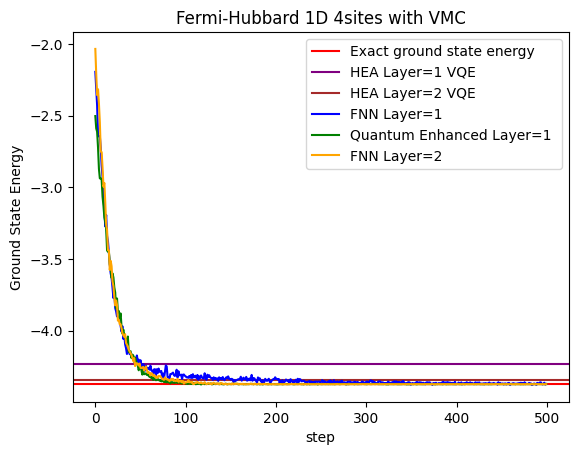

In [44]:
ed_energies = np.linalg.eigvalsh(ham.to_dense())

with open(f"./fermions_test0723_FNN_1.log") as f:
    data_FNN_1 = json.load(f)
    
with open(f"./fermions_test0723_FNN_2.log") as f:
    data_FNN_2 = json.load(f)
    
with open(f"./fermions_test0723_FNN_3.log") as f:
    data_FNN_3 = json.load(f)
    

x_FNN_1 = data_FNN_1["Energy"]["iters"]
y_FNN_1 = data_FNN_1["Energy"]["Mean"]

x_FNN_2 = data_FNN_2["Energy"]["iters"]
y_FNN_2 = data_FNN_2["Energy"]["Mean"]

x_FNN_3 = data_FNN_3["Energy"]["iters"]
y_FNN_3 = data_FNN_3["Energy"]["Mean"]

# plot the energy levels
plt.axhline(ed_energies[0], color="red", label="Exact ground state energy")
plt.axhline(ed_energies[0]+0.143, color="purple", label="HEA Layer=1 VQE")
plt.axhline(ed_energies[0]+0.027, color="brown", label="HEA Layer=2 VQE")
# for e in ed_energies[1:]:
#     plt.axhline(e, color="black")
plt.plot(x_FNN_1, y_FNN_1, color="blue", label="FNN Layer=1")
plt.plot(x_FNN_2, y_FNN_2, color="green", label="Quantum Enhanced Layer=1 ")
plt.plot(x_FNN_3, y_FNN_3, color="orange", label="FNN Layer=2")
plt.title("Fermi-Hubbard 1D 4sites with VMC")
plt.legend()
plt.xlabel("step")
plt.ylabel("Ground State Energy")
plt.show()

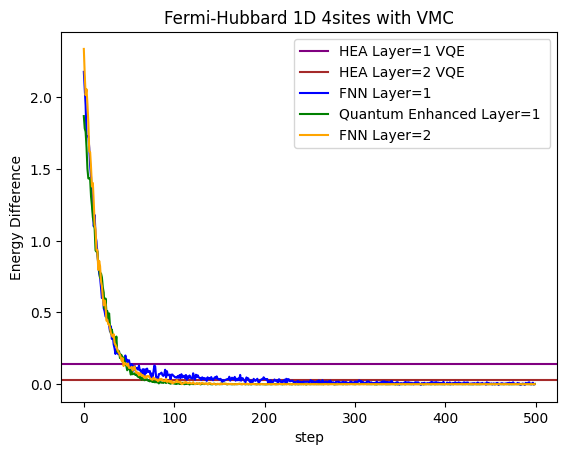

In [45]:
# plt.axhline(ed_energies[0], color="red", label="Exact ground state energy")
# for e in ed_energies[1:]:
#     plt.axhline(e, color="black")
y_FNN_1_shifted = np.array(y_FNN_1) - ed_energies[0]
y_FNN_2_shifted = np.array(y_FNN_2) - ed_energies[0]
y_FNN_3_shifted = np.array(y_FNN_3) - ed_energies[0]
plt.axhline(0.143, color="purple", label="HEA Layer=1 VQE")
plt.axhline(0.027, color="brown", label="HEA Layer=2 VQE")

plt.plot(x_FNN_1, y_FNN_1_shifted, color="blue", label="FNN Layer=1")
plt.plot(x_FNN_2, y_FNN_2_shifted, color="green", label="Quantum Enhanced Layer=1 ")
plt.plot(x_FNN_3, y_FNN_3_shifted, color="orange", label="FNN Layer=2")
plt.title("Fermi-Hubbard 1D 4sites with VMC")
plt.legend()
plt.xlabel("step")
plt.ylabel("Energy Difference")
plt.show()

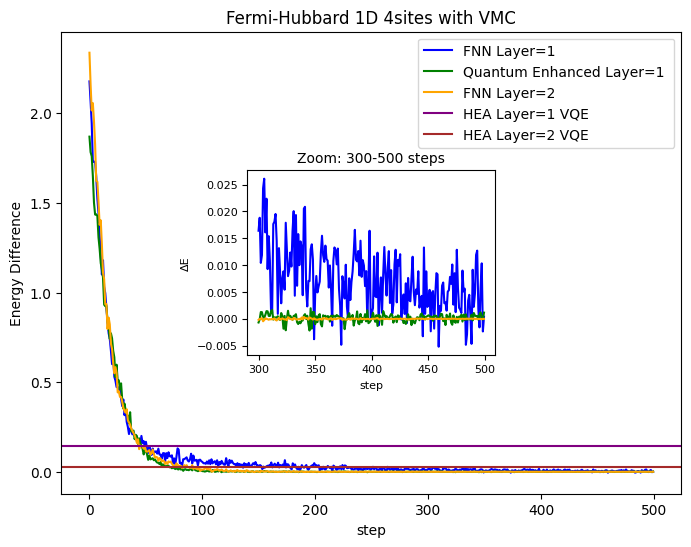

In [48]:
# 主图
plt.figure(figsize=(8,6))
plt.plot(x_FNN_1, y_FNN_1_shifted, color="blue", label="FNN Layer=1")
plt.plot(x_FNN_2, y_FNN_2_shifted, color="green", label="Quantum Enhanced Layer=1 ")
plt.plot(x_FNN_3, y_FNN_3_shifted, color="orange", label="FNN Layer=2")
plt.axhline(0.143, color="purple", label="HEA Layer=1 VQE")
plt.axhline(0.027, color="brown", label="HEA Layer=2 VQE")
plt.title("Fermi-Hubbard 1D 4sites with VMC")
plt.legend()
plt.xlabel("step")
plt.ylabel("Energy Difference")

# 添加小图
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

ax_inset = inset_axes(plt.gca(), width="40%", height="40%", loc='center')
# 选取最后300-500轮的数据
start, end = 300, 500
ax_inset.plot(x_FNN_1[start:end], y_FNN_1_shifted[start:end], color="blue")
ax_inset.plot(x_FNN_2[start:end], y_FNN_2_shifted[start:end], color="green")
ax_inset.plot(x_FNN_3[start:end], y_FNN_3_shifted[start:end], color="orange")
# ax_inset.axhline(0.143, color="brown", label="HEA Layer=2 VQE")
ax_inset.set_title("Zoom: 300-500 steps", fontsize=10)
ax_inset.set_xlabel("step", fontsize=8)
ax_inset.set_ylabel("ΔE", fontsize=8)
ax_inset.tick_params(labelsize=8)

plt.show()